In [ ]:
# All Import Here
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import CountVectorizer


In [ ]:
# Load Dateset
df=pd.read_csv('Resume.csv')
df.head(5)


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [ ]:
#claning data
def clean_text(text):
    text=text.lower()
    text=re.sub(r'[^a-zA-Z]',' ',text)
    text=re.sub(r'\s+',' ',text)
    return text

df['Resume_str']=df['Resume_str'].apply(clean_text)

In [ ]:
# Size of data
df.shape

(2484, 4)

In [ ]:
# Inofrmaition of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [ ]:
#  Check mising value
df.isnull().sum()

ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

In [ ]:
#Multiple Values
df['Category'].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

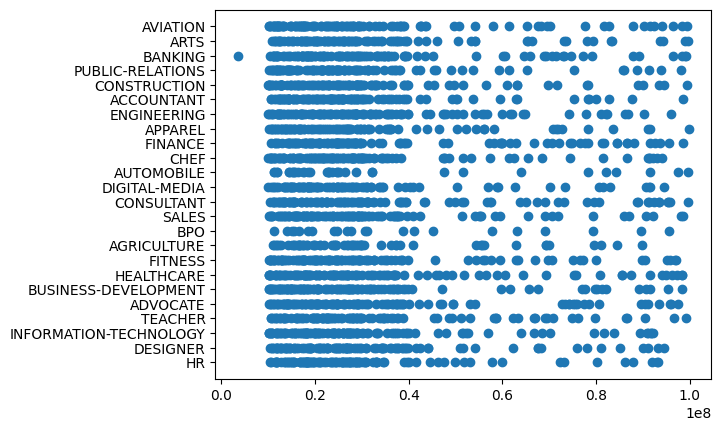

In [ ]:
# plot values 
plt.scatter(df['ID'],df['Category'])

In [ ]:
# Labels of colunms
X=df['Resume_str']
Y=df['Category']

In [ ]:
# convert text
vectorizer=TfidfVectorizer(stop_words="english",
                           max_features=5000,
                           ngram_range=(1,2))
X=vectorizer.fit_transform(X)

In [ ]:
# model tarin
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [ ]:
# model call
model=RandomForestClassifier()
model.fit(X_train,Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
# from sklearn.naive_bayes import MultinomialNB
# model=MultinomialNB()
# model.fit(X_train,Y_train)

# from sklearn.linear_model import LogisticRegression
# model=LogisticRegression()

# model.fit(X_train,Y_train)

In [ ]:
# predict accuracy values
pred=model.predict(X_test)
print("Accuracy_score:",accuracy_score(Y_test,pred))

Accuracy_score: 0.7605633802816901


In [20]:
sample_resume=["Data Scientist with 2 years of experiance in Machine Learing,"
"Deep Learning,Natural Language Processing and Predictive Modeling, Skilled in Python,Pandas,Numpy,Scikit-learn,TensorFlow,SQL,Built data analysis projects,dashborads,AI-based solution."
"Experiance in data preprocessing,feature engineering,and model avaluation. "]

sample_tfidf=vectorizer.transform(sample_resume)
prediction=model.predict(sample_tfidf)
print("Predicted Category:",prediction[0])

Predicted Category: ENGINEERING


In [ ]:
cv=CountVectorizer(stop_words='english',max_features=20)
X_counts=cv.fit_transform(df['Resume_str'])
word_freq=X_counts.toarray().sum(axis=0)
words=cv.get_feature_names_out()

plt.figure(figsize=(10,5))
sns.barplot(X=word_freq,Y=words)
plt.title("Top 20 Most Frequent Words in Resume")
plt.show()

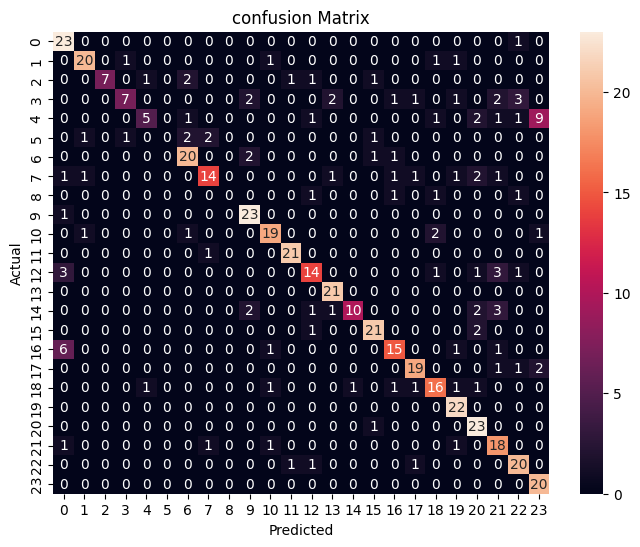

In [ ]:
# plot confusion matrix
cm=confusion_matrix(Y_test,pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d')
plt.title("confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

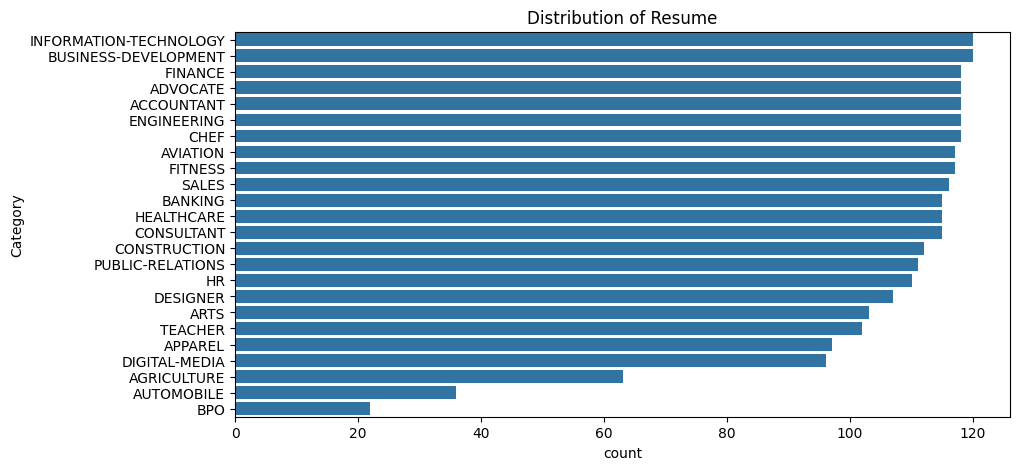

In [ ]:
# plot-Countplot figure
plt.figure(figsize=(10,5))
sns.countplot(y=df['Category'],order=df['Category'].value_counts().index)
plt.title('Distribution of Resume')
plt.show()

In [ ]:
https://github.com/rajatcse9-a11y/News-category-Classification-ML.git